# Download project data from GitHub

In [1]:
# Clone the public repository (No tokens or passwords required!)
%cd /content
!rm -rf gtsrb_repo
!git clone https://github.com/meiravnitzan/gtsrb_repo.git
%cd /content/gtsrb_repo


/content
Cloning into 'gtsrb_repo'...
remote: Enumerating objects: 289, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 289 (delta 9), reused 7 (delta 2), pack-reused 270 (from 2)
Receiving objects: 100% (289/289), 23.39 MiB | 28.15 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Filtering content: 100% (2/2), 256.58 MiB | 11.86 MiB/s, done.
/content/gtsrb_repo


# Environment setup

In [2]:
!pip install -q -r requirements-gen.txt

# Download the Train and Test sets from GTSRB official web site


In [3]:
!python download_data.py

[download] https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -> data/GTSRB_Final_Training_Images.zip
[download] https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -> data/GTSRB_Final_Test_Images.zip
[download] https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -> data/GTSRB_Final_Test_GT.zip
[extract] data/GTSRB_Final_Training_Images.zip -> data
[extract] data/GTSRB_Final_Test_Images.zip -> data
[extract] data/GTSRB_Final_Test_GT.zip -> data

Done.
Training images: data/GTSRB/Final_Training/Images
Test images:     data/GTSRB/Final_Test/Images
Test CSV:        data/GT-final_test.csv


# Set the demo

In [25]:
%run /content/gtsrb_repo/demo.py

<Figure size 640x480 with 0 Axes>

### Find a good example image for the demo

In [26]:
bad_22 = list_misclassified_images_for_class(22)
len(bad_22), bad_22[:5]

(30,
 [{'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/00339.ppm',
   'true_label': 22,
   'pred_label': 28,
   'confidence': 0.3561580181121826},
  {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/00513.ppm',
   'true_label': 22,
   'pred_label': 25,
   'confidence': 0.5132661461830139},
  {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/03457.ppm',
   'true_label': 22,
   'pred_label': 25,
   'confidence': 0.271933913230896},
  {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/03896.ppm',
   'true_label': 22,
   'pred_label': 25,
   'confidence': 0.39530351758003235},
  {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/04055.ppm',
   'true_label': 22,
   'pred_label': 25,
   'confidence': 0.5874647498130798}])

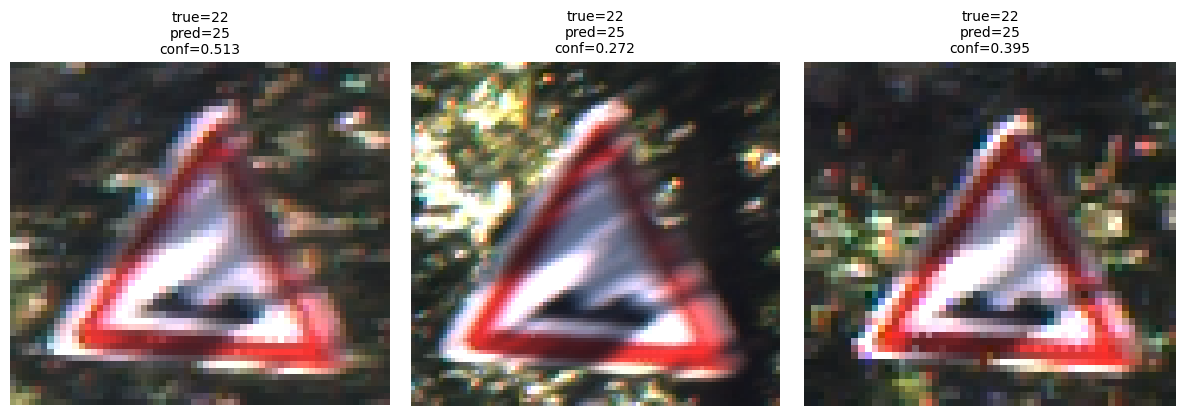

[{'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/00513.ppm',
  'true_label': 22,
  'pred_label': 25,
  'confidence': 0.5132661461830139},
 {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/03457.ppm',
  'true_label': 22,
  'pred_label': 25,
  'confidence': 0.271933913230896},
 {'image_path': '/content/gtsrb_repo/data/GTSRB/Final_Test/Images/03896.ppm',
  'true_label': 22,
  'pred_label': 25,
  'confidence': 0.39530351758003235}]

In [27]:
show_misclassified_examples(22, predicted_as=25, max_show=3)

# Show a misclassified image before and after added augmentation to training set

## Classification using Baseline training

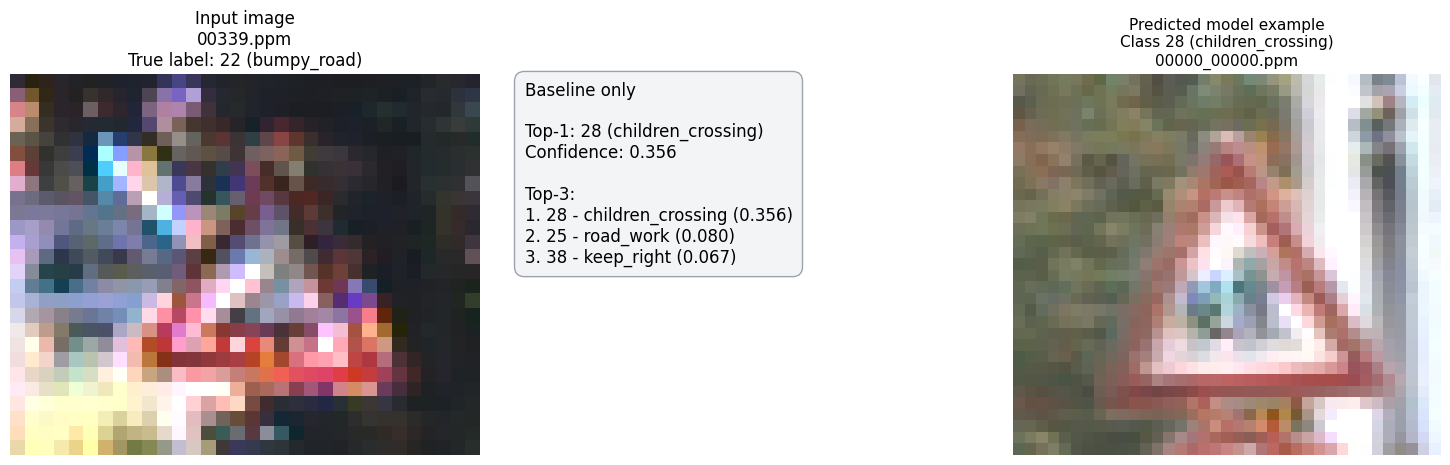

In [28]:
img = "/content/gtsrb_repo/data/GTSRB/Final_Test/Images/00339.ppm"
show_one_model(baseline_model, img, model_name="Baseline only", true_label=22)

## Augmented images
Note: at this point I generated images only for class 22 (80 generated images)

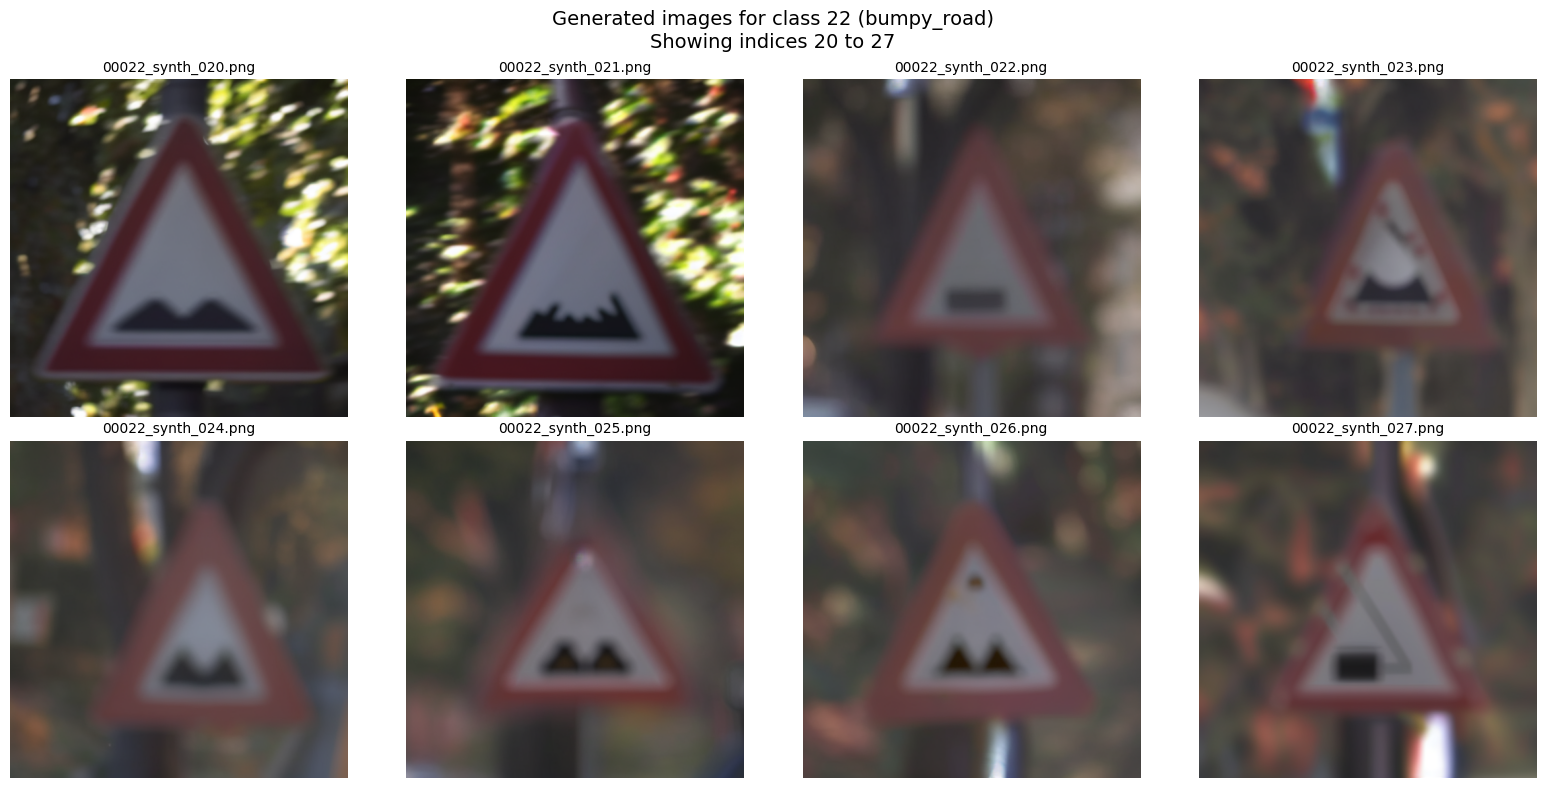

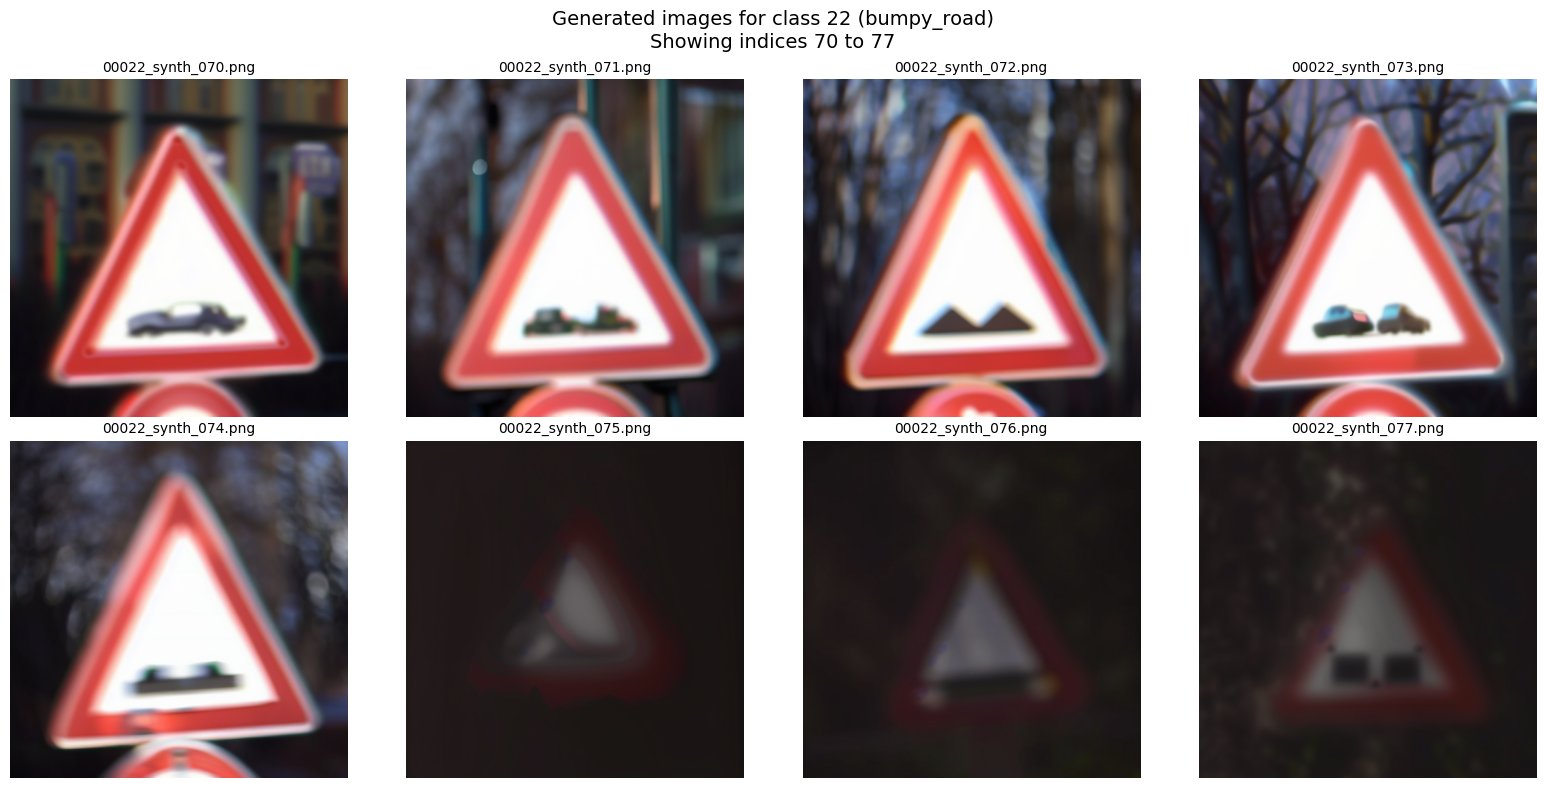

In [34]:
show_generated_images(22, 20, 27)
show_generated_images(22, 70, 77)

## Classification using Baseline+Augmented training

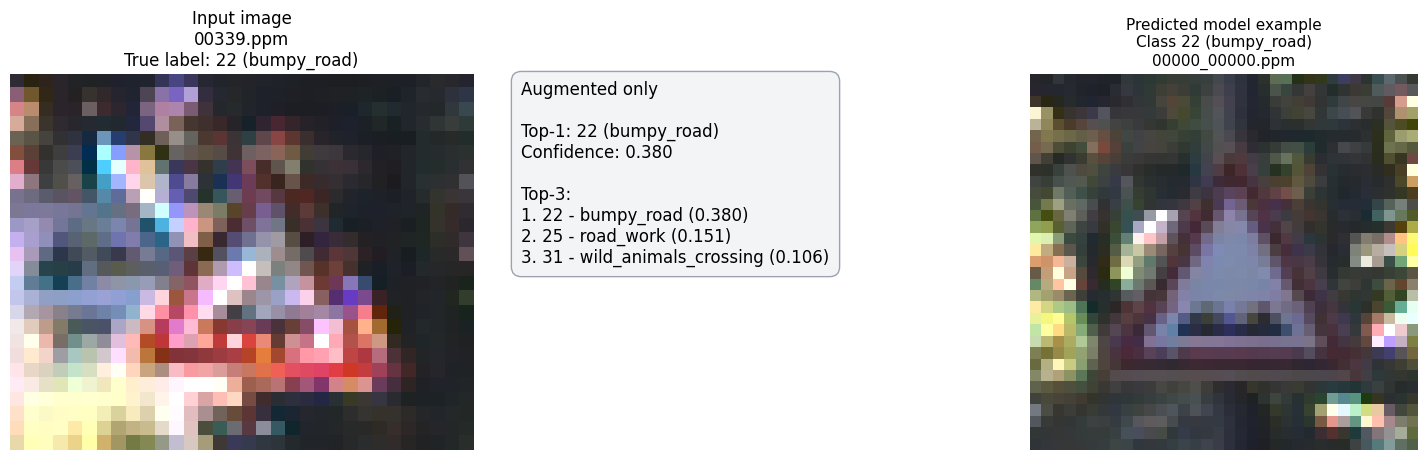

In [23]:
img = "/content/gtsrb_repo/data/GTSRB/Final_Test/Images/00339.ppm"
show_one_model(augmented_model, img, model_name="Augmented only", true_label=22)